In [1]:
""" 
The \(XXZ\) Heisenberg Chain (Anisotropic)This variation introduces an asymmetry parameter (\(\Delta \)). 
The \(Z\)-direction interaction has a different strength than the \(X\) and \(Y\) directions. 
This is highly popular for VQE benchmarks because changing \(\Delta \) completely changes the quantum phase of the matter.
"""

<>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
<>:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
/tmp/ipykernel_1031/205948996.py:2: SyntaxWarning: "\(" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\("? A raw string is also an option.
  The \(XXZ\) Heisenberg Chain (Anisotropic)This variation introduces an asymmetry parameter (\(\Delta \)).


' \nThe \\(XXZ\\) Heisenberg Chain (Anisotropic)This variation introduces an asymmetry parameter (\\(\\Delta \\)). \nThe \\(Z\\)-direction interaction has a different strength than the \\(X\\) and \\(Y\\) directions. \nThis is highly popular for VQE benchmarks because changing \\(\\Delta \\) completely changes the quantum phase of the matter.\n'

Step 000: Cost = -0.260036
Step 010: Cost = -2.358521
Step 020: Cost = -2.998951
Step 030: Cost = -3.018234
Step 040: Cost = -3.028068
Step 050: Cost = -3.037010
Step 060: Cost = -3.048106
Step 070: Cost = -3.063277
Step 080: Cost = -3.084674
Step 090: Cost = -3.115153
Step 100: Cost = -3.158079
Step 110: Cost = -3.215475
Step 120: Cost = -3.283089
Step 130: Cost = -3.346322
Step 140: Cost = -3.389831
Step 150: Cost = -3.412536
Step 160: Cost = -3.422732
Step 170: Cost = -3.427241
Step 180: Cost = -3.429433
Step 190: Cost = -3.430749
Step 000: Cost = 0.733861
Step 010: Cost = -2.167856
Step 020: Cost = -3.342062
Step 030: Cost = -3.451579
Step 040: Cost = -3.459457
Step 050: Cost = -3.463700
Step 060: Cost = -3.466260
Step 070: Cost = -3.467807
Step 080: Cost = -3.468747
Step 090: Cost = -3.469323
Step 100: Cost = -3.469682
Step 110: Cost = -3.469907
Step 120: Cost = -3.470051
Step 130: Cost = -3.470142
Step 140: Cost = -3.470202
Step 150: Cost = -3.470240
Step 160: Cost = -3.470265
St

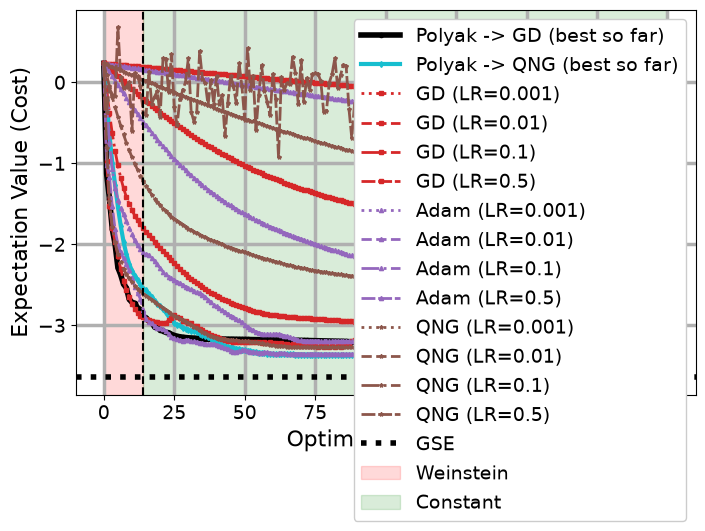

In [4]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 4
num_layers = 2
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

plt.figure(figsize=(8, 5))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

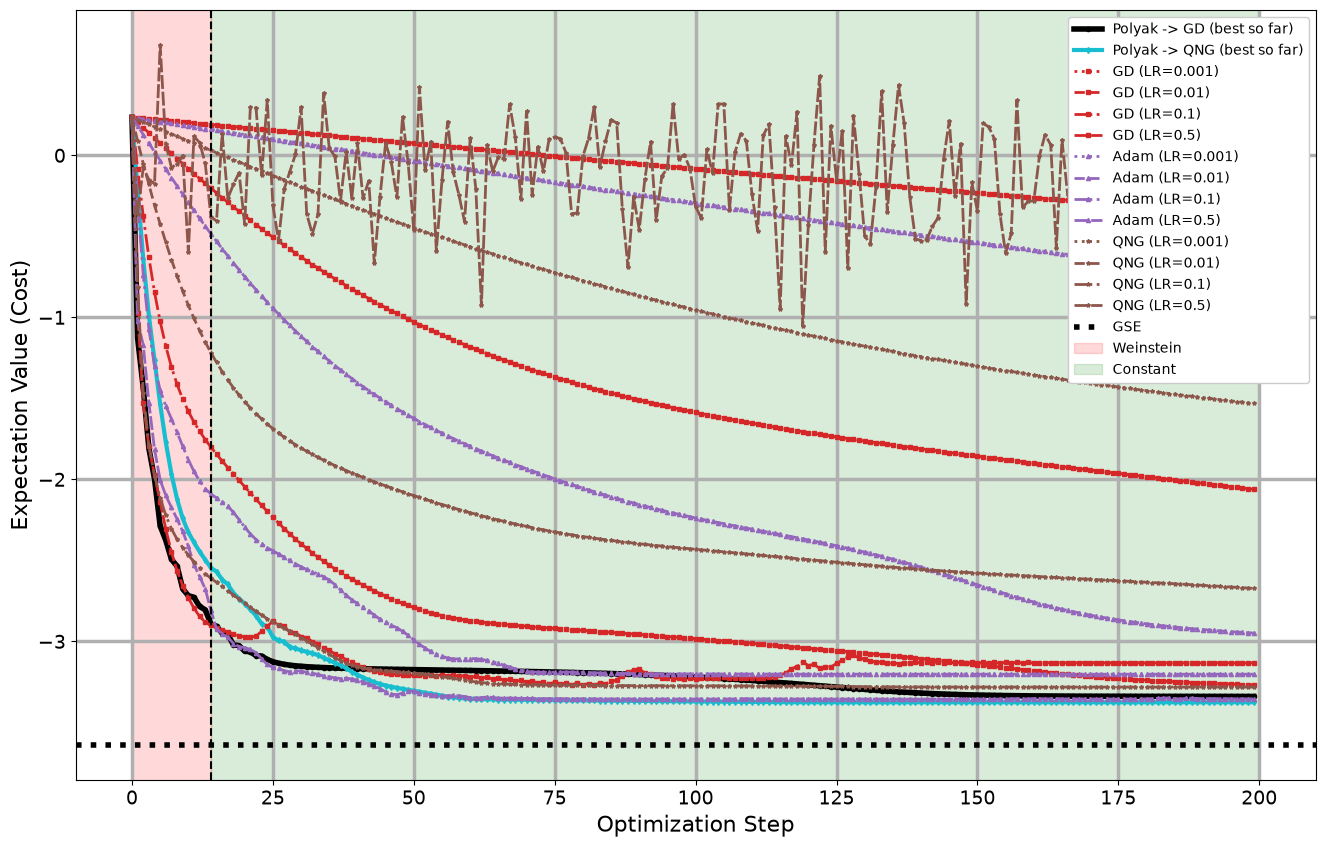

In [5]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [6]:
# !pip install pennylane-lightning[gpu]

Step 000: Cost = 0.806836
Step 010: Cost = -4.389714
Step 020: Cost = -4.532492
Step 030: Cost = -4.587303
Step 040: Cost = -4.596644
Step 050: Cost = -4.600262
Step 060: Cost = -4.601921
Step 070: Cost = -4.602758
Step 080: Cost = -4.603198
Step 090: Cost = -4.603435
Step 100: Cost = -4.603563
Step 110: Cost = -4.603633
Step 120: Cost = -4.603671
Step 130: Cost = -4.603693
Step 140: Cost = -4.603705
Step 150: Cost = -4.603712
Step 160: Cost = -4.603717
Step 170: Cost = -4.603720
Step 180: Cost = -4.603722
Step 190: Cost = -4.603724
Step 000: Cost = 0.710841
Step 010: Cost = -3.255379
Step 020: Cost = -3.857719
Step 030: Cost = -4.457293
Step 040: Cost = -4.480382
Step 050: Cost = -4.492912
Step 060: Cost = -4.503786
Step 070: Cost = -4.514109
Step 080: Cost = -4.524228
Step 090: Cost = -4.534305
Step 100: Cost = -4.544474
Step 110: Cost = -4.554880
Step 120: Cost = -4.565672
Step 130: Cost = -4.576982
Step 140: Cost = -4.588902
Step 150: Cost = -4.601459
Step 160: Cost = -4.614567
Ste

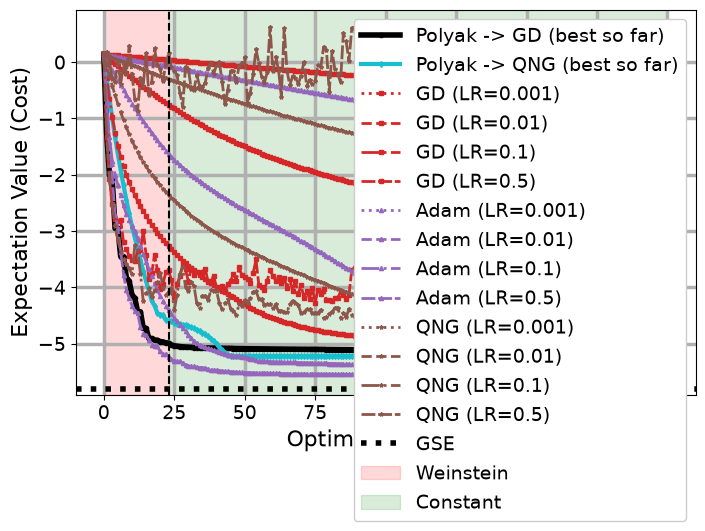

In [10]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 6
num_layers = 3
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

plt.figure(figsize=(8, 5))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

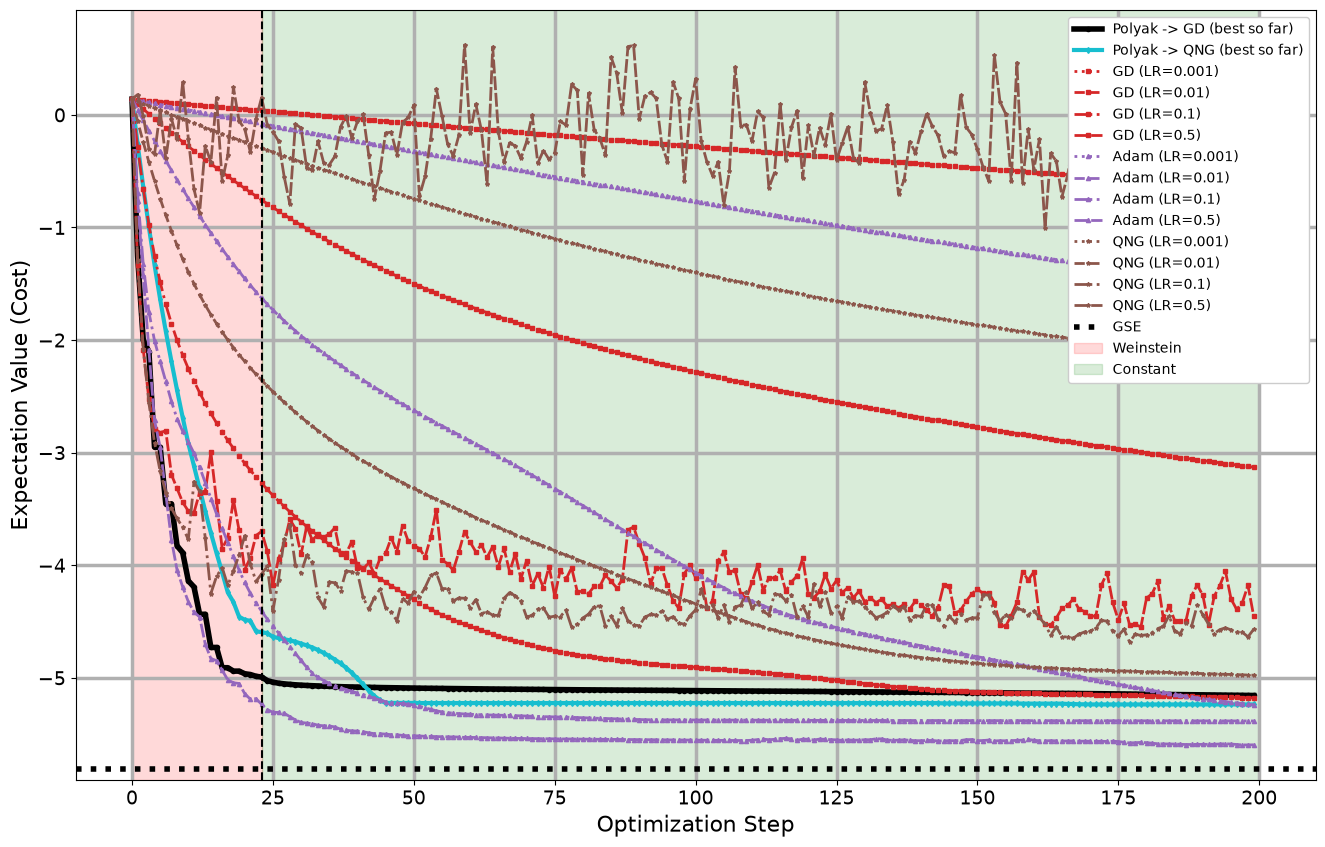

In [11]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

Step 000: Cost = -0.515511
Step 010: Cost = -5.313173
Step 020: Cost = -5.575991
Step 030: Cost = -5.747880
Step 040: Cost = -5.860560
Step 050: Cost = -5.954609
Step 060: Cost = -6.049032
Step 070: Cost = -6.160264
Step 080: Cost = -6.292688
Step 090: Cost = -6.422958
Step 100: Cost = -6.522800
Step 110: Cost = -6.597483
Step 120: Cost = -6.661914
Step 130: Cost = -6.721049
Step 140: Cost = -6.775130
Step 150: Cost = -6.825155
Step 160: Cost = -6.873698
Step 170: Cost = -6.923718
Step 180: Cost = -6.977914
Step 190: Cost = -7.039144
Step 000: Cost = -0.469495
Step 010: Cost = -5.624572
Step 020: Cost = -6.570972
Step 030: Cost = -7.278028
Step 040: Cost = -7.330775
Step 050: Cost = -7.351757
Step 060: Cost = -7.365874
Step 070: Cost = -7.378625
Step 080: Cost = -7.391304
Step 090: Cost = -7.404191
Step 100: Cost = -7.417273
Step 110: Cost = -7.430447
Step 120: Cost = -7.443604
Step 130: Cost = -7.456691
Step 140: Cost = -7.469728
Step 150: Cost = -7.482766
Step 160: Cost = -7.495796
S

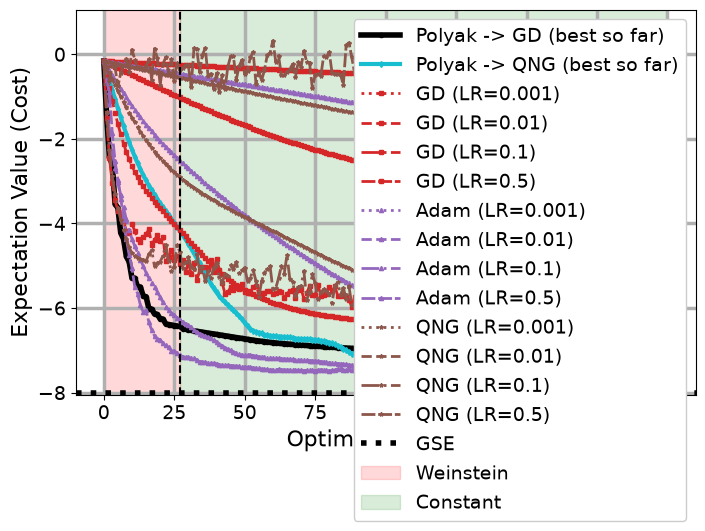

In [12]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 8
num_layers = 4
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

plt.figure(figsize=(8, 5))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

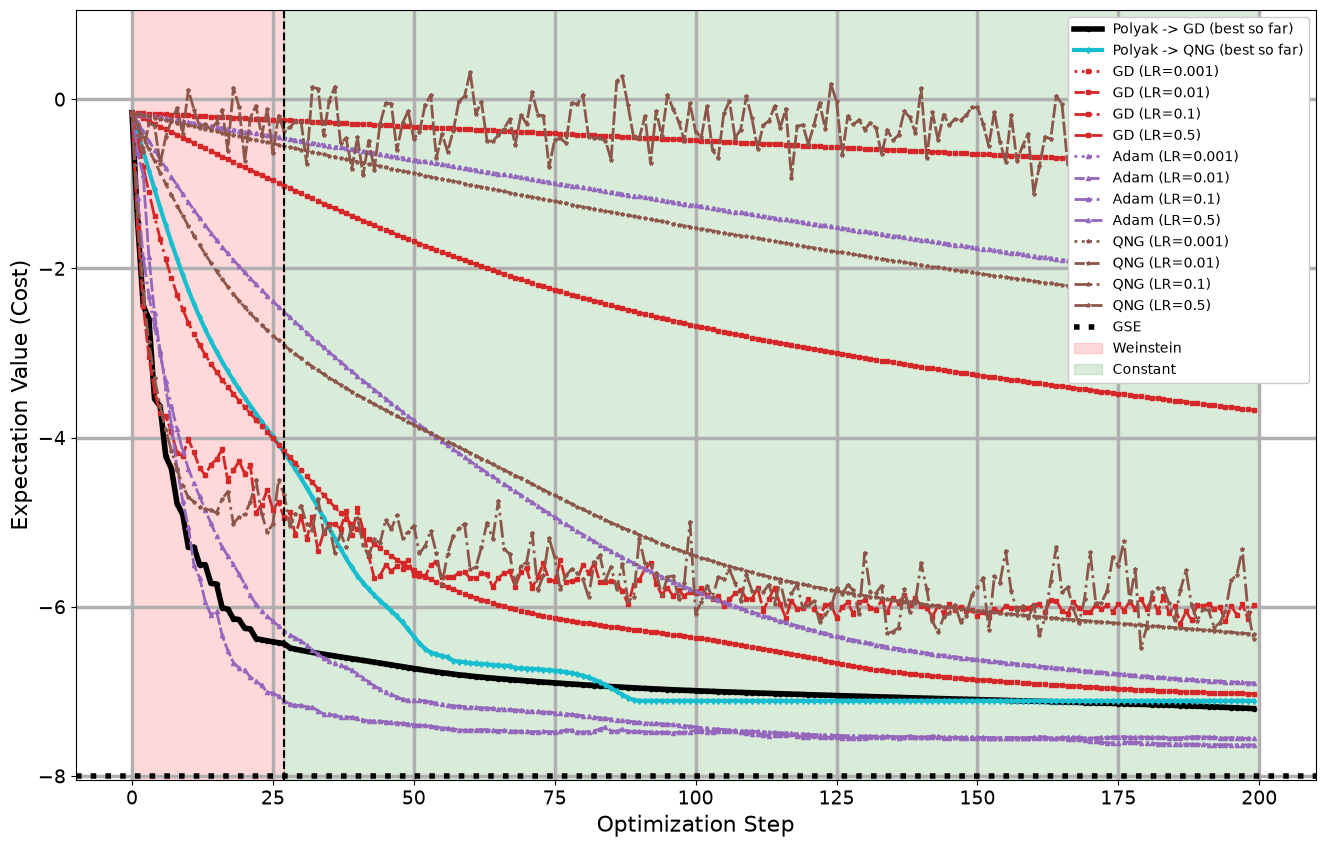

In [13]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

Step 000: Cost = 0.176848
Step 010: Cost = -7.317019
Step 020: Cost = -8.924388
Step 030: Cost = -9.000505
Step 040: Cost = -9.061358
Step 050: Cost = -9.093399
Step 060: Cost = -9.112077
Step 070: Cost = -9.124178
Step 080: Cost = -9.132970
Step 090: Cost = -9.140104
Step 100: Cost = -9.146466
Step 110: Cost = -9.152566
Step 120: Cost = -9.158731
Step 130: Cost = -9.165210
Step 140: Cost = -9.172243
Step 150: Cost = -9.180133
Step 160: Cost = -9.189317
Step 170: Cost = -9.200490
Step 180: Cost = -9.214834
Step 190: Cost = -9.234489
Step 000: Cost = -0.342901
Step 010: Cost = -5.278404
Step 020: Cost = -7.596335
Step 030: Cost = -8.118184
Step 040: Cost = -8.420848
Step 050: Cost = -8.451776
Step 060: Cost = -8.477609
Step 070: Cost = -8.501800
Step 080: Cost = -8.524177
Step 090: Cost = -8.544641
Step 100: Cost = -8.563409
Step 110: Cost = -8.580845
Step 120: Cost = -8.597309
Step 130: Cost = -8.613091
Step 140: Cost = -8.628422
Step 150: Cost = -8.643495
Step 160: Cost = -8.658503
St

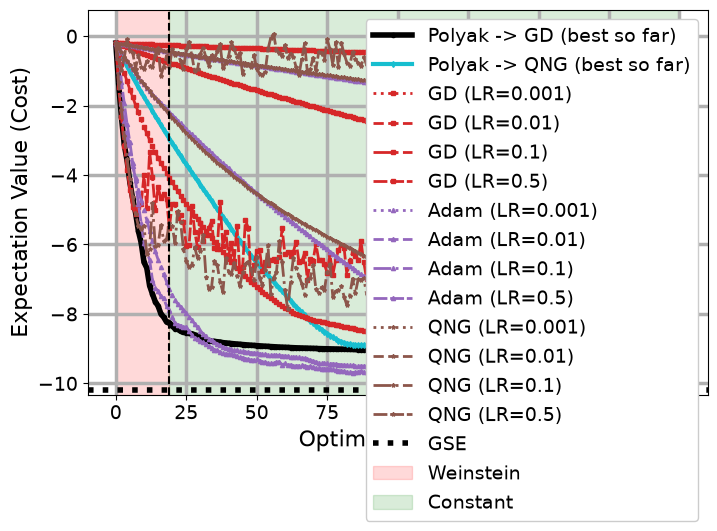

In [18]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 10
num_layers = 5
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

plt.figure(figsize=(8, 5))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

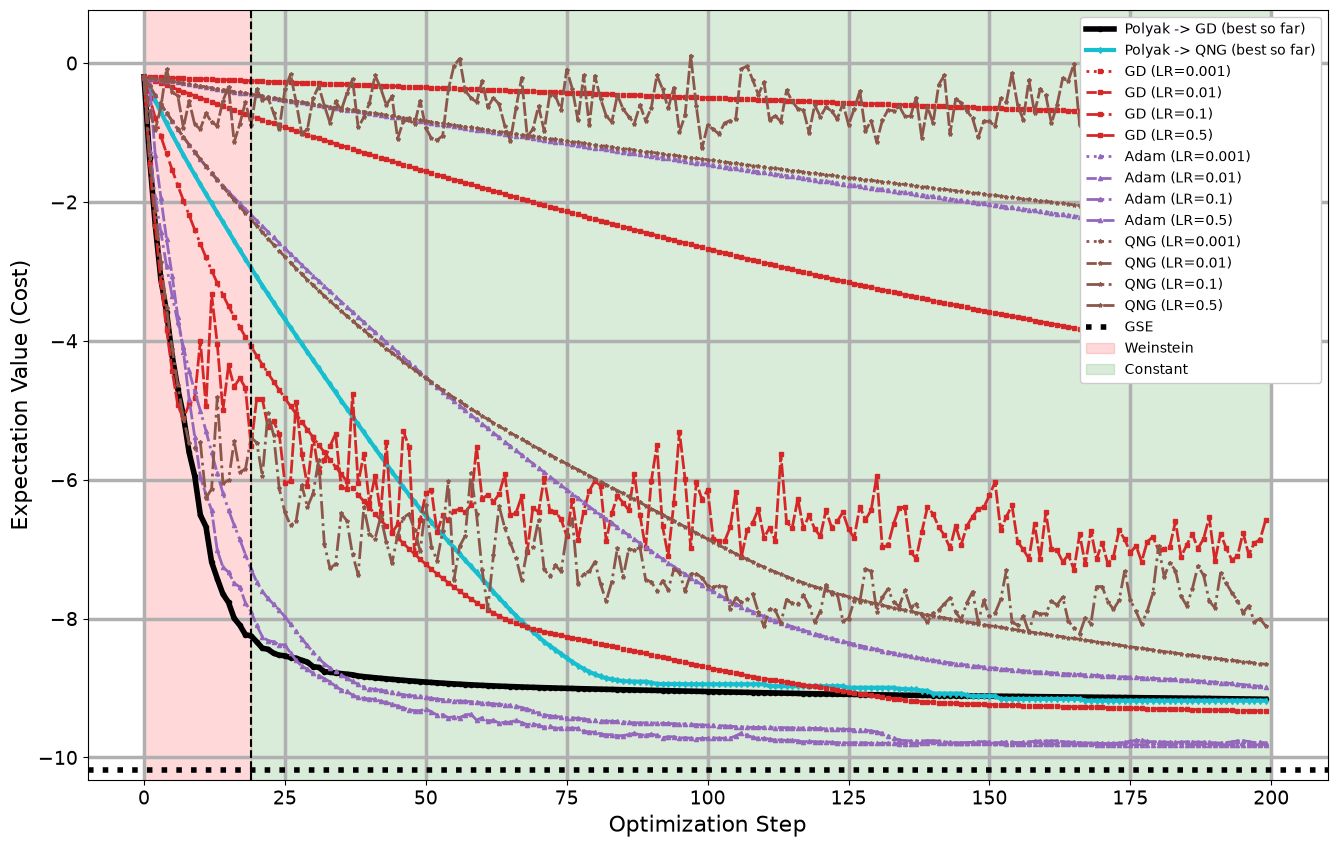

In [19]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [24]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 12
num_layers = 6
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

# plt.figure(figsize=(8, 5))
# plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
# plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
# styles = [':', '--', '-.', (0, (5, 1))]
# for j, lr in enumerate(sgd_lrs):
#     plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
# for j, lr in enumerate(adam_lrs):
#     plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
# for j, lr in enumerate(qng_lrs):
#     plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
# plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
# regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
# colors = {"Weinstein": "red", "Constant": "green"}
# labeled = set()
# start = 0
# for i in range(1, len(regimes) + 1):
#     if i == len(regimes) or regimes[i] != regimes[start]:
#         r = regimes[start]
#         plt.axvspan(start, i, color=colors[r], alpha=0.15,
#                     label=r if r not in labeled else None)
#         labeled.add(r)
#         if i < len(regimes):
#             plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
#         start = i
# plt.xlabel("Optimization Step", fontsize=16)
# plt.ylabel("Expectation Value (Cost)", fontsize=16)
# plt.tick_params(labelsize=14)
# plt.legend(fontsize=14, framealpha=1, loc='upper right')
# plt.grid(True, linewidth=2.5)
# plt.show()

Step 000: Cost = -0.220649
Step 010: Cost = -6.634606
Step 020: Cost = -9.980518
Step 030: Cost = -9.877298
Step 040: Cost = -10.812413
Step 050: Cost = -10.873923
Step 060: Cost = -10.934878
Step 070: Cost = -11.000684
Step 080: Cost = -11.076146
Step 090: Cost = -11.176834
Step 100: Cost = -11.339341
Step 110: Cost = -11.562331
Step 120: Cost = -11.721706
Step 130: Cost = -11.807065
Step 140: Cost = -11.872153
Step 150: Cost = -11.929053
Step 160: Cost = -11.973280
Step 170: Cost = -12.001177
Step 180: Cost = -12.015560
Step 190: Cost = -12.022165
Step 000: Cost = -0.182294
Step 010: Cost = -6.368008
Step 020: Cost = -10.026263
Step 030: Cost = -8.959989
Step 040: Cost = -11.879930
Step 050: Cost = -11.898196
Step 060: Cost = -11.910716
Step 070: Cost = -11.922579
Step 080: Cost = -11.934231
Step 090: Cost = -11.945616
Step 100: Cost = -11.956475
Step 110: Cost = -11.966466
Step 120: Cost = -11.975271
Step 130: Cost = -11.982699
Step 140: Cost = -11.988735
Step 150: Cost = -11.993518

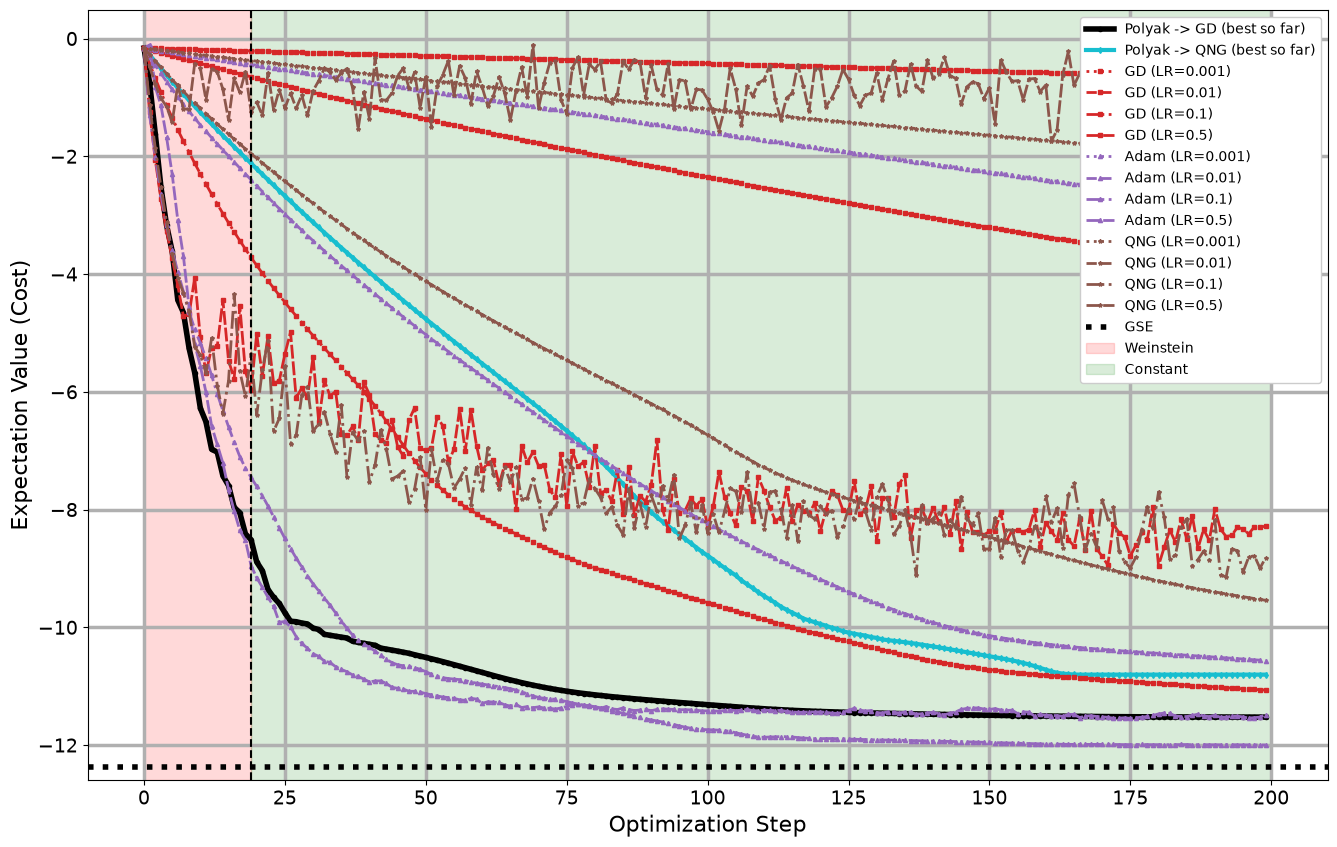

In [25]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [1]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 14
num_layers = 7
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

# plt.figure(figsize=(8, 5))
# plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
# plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
# styles = [':', '--', '-.', (0, (5, 1))]
# for j, lr in enumerate(sgd_lrs):
#     plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
# for j, lr in enumerate(adam_lrs):
#     plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
# for j, lr in enumerate(qng_lrs):
#     plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
# plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
# regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
# colors = {"Weinstein": "red", "Constant": "green"}
# labeled = set()
# start = 0
# for i in range(1, len(regimes) + 1):
#     if i == len(regimes) or regimes[i] != regimes[start]:
#         r = regimes[start]
#         plt.axvspan(start, i, color=colors[r], alpha=0.15,
#                     label=r if r not in labeled else None)
#         labeled.add(r)
#         if i < len(regimes):
#             plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
#         start = i
# plt.xlabel("Optimization Step", fontsize=16)
# plt.ylabel("Expectation Value (Cost)", fontsize=16)
# plt.tick_params(labelsize=14)
# plt.legend(fontsize=14, framealpha=1, loc='upper right')
# plt.grid(True, linewidth=2.5)
# plt.show()

Step 000: Cost = 0.160407
Step 010: Cost = -7.003727
Step 020: Cost = -10.122673
Step 030: Cost = -10.580446
Step 040: Cost = -11.165156
Step 050: Cost = -11.640002
Step 060: Cost = -11.857114
Step 070: Cost = -12.010171
Step 080: Cost = -12.133059
Step 090: Cost = -12.235146
Step 100: Cost = -12.325080
Step 110: Cost = -12.407642
Step 120: Cost = -12.482838
Step 130: Cost = -12.551315
Step 140: Cost = -12.617810
Step 150: Cost = -12.687935
Step 160: Cost = -12.765650
Step 170: Cost = -12.854366
Step 180: Cost = -12.955315
Step 190: Cost = -13.060635
Step 000: Cost = -0.118275
Step 010: Cost = -7.933119
Step 020: Cost = -10.930072
Step 030: Cost = -12.077560
Step 040: Cost = -13.111112
Step 050: Cost = -13.642554
Step 060: Cost = -13.660897
Step 070: Cost = -13.674195
Step 080: Cost = -13.684356
Step 090: Cost = -13.692470
Step 100: Cost = -13.699225
Step 110: Cost = -13.705055
Step 120: Cost = -13.710231
Step 130: Cost = -13.714928
Step 140: Cost = -13.719257
Step 150: Cost = -13.7232

plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [3]:
# Alright guys I finally have some code up and running that I think will be a solid start for benchmarking. I might update it later but the idea is simple. You will need to do this before running the code:

# 1) prepare GPU enviornment (without GPU's this will become way too slove)
# 2) update path to save results
# 3) run with 4q 2layer, 6 qubits 3 layers, 8 qubits 4 layers, 10 qubits 5 layers, 12 qubits 6 layers for now

# Here it what the code does:
# we run *polyak gd / qng* and *compare it with constant lr (qng/gd/adam)*. We will run each optimizer 5 times in total and take the mean run. For the constant learning rates we try 0.001, 0.01, 0.1 and 0.5 to get a good feel for the performance. 


import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import numpy as std_np
import json
import os

num_qubits = 16
num_layers = 8
n_steps = 200
dev = qml.device("lightning.gpu", wires=num_qubits)

# ---------Ising model----------------------
# h_field = 1.0
# coeffs = []
# observables = []
# for i in range(num_qubits - 1):
#     coeffs.append(-1.0)
#     observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
# for i in range(num_qubits):
#     coeffs.append(-h_field)
#     observables.append(qml.PauliX(i))
# H = qml.Hamiltonian(coeffs, observables)

# h1_norm = np.sum(np.abs(coeffs))



# ----------H2 molecule---------------
# from pennylane import qchem

# # Define molecule geometry (H2 molecule)
# symbols = ["H", "H"]
# coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

# # Generate molecular Hamiltonian and overwrite num_qubits dynamically
# H, num_qubits = qchem.molecular_hamiltonian(symbols, coordinates)



# --- XXZ Hamiltonian Definition ---
def get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5):
    coeffs = []
    observables = []
    
    for i in range(num_qubits - 1):
        # X-X and Y-Y share the base coupling J
        coeffs.extend([-J, -J])
        observables.extend([
            qml.PauliX(i) @ qml.PauliX(i+1),
            qml.PauliY(i) @ qml.PauliY(i+1)
        ])
        # Z-Z has a modified coupling (J * delta)
        coeffs.append(-J * delta)
        observables.append(qml.PauliZ(i) @ qml.PauliZ(i+1))
        
    return qml.Hamiltonian(coeffs, observables)

# Construct Hamiltonian & calculate 1-norm coefficient sum
H = get_xxz_hamiltonian(num_qubits, J=1.0, delta=0.5)
h1_norm = np.sum(np.abs(H.coeffs))





def ansatz(params):
    for layer in range(num_layers):
        for q in range(num_qubits):
            qml.RX(params[layer, q, 0], wires=q)
            qml.RY(params[layer, q, 1], wires=q)
        for q in range(num_qubits - 1):
            qml.CNOT(wires=[q, q+1])

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params)
    return qml.expval(H)

@qml.qnode(dev)
def var_fn(params):
    ansatz(params)
    return qml.var(H)

eigvals = np.linalg.eigvalsh(qml.matrix(H, wire_order=range(num_qubits)))
delta = eigvals[1] - eigvals[0]
grad_fn = qml.grad(cost_fn)

sgd_lrs = [0.001, 0.01, 0.1, 0.5]
adam_lrs = [0.001, 0.01, 0.1, 0.5]
qng_lrs = [0.001, 0.01, 0.1, 0.5]

all_costs, all_best, all_qng_pc, all_best_qng, all_switch, all_switch_qng = [], [], [], [], [], []
all_sgd = {lr: [] for lr in sgd_lrs}
all_adam = {lr: [] for lr in adam_lrs}
all_qng = {lr: [] for lr in qng_lrs}

for _ in range(5):
    params = np.random.normal(0, np.pi, (num_layers, num_qubits, 2), requires_grad=True)
    initial_params = params.copy()

    costs = []
    regimes = []
    best_cost = np.inf
    best_params = params.copy()
    no_improve = 0
    patience = 5
    refining = False
    lr_const = None
    switch = None

    for step in range(n_steps):
        cost = cost_fn(params)
        costs.append(cost)
        if step % 10 == 0:
          print(f"Step {step:03d}: Cost = {cost:.6f}")

        if cost < best_cost:
            best_cost = cost
            best_params = params.copy()
            no_improve = 0
        else:
            no_improve += 1

        if not refining and no_improve >= patience:
            refining = True
            params = best_params.copy()
            lr_const = 0.1
            no_improve = 0
            switch = step + 1

        grad = grad_fn(params)

        if not refining:
            var = var_fn(params)
            std = np.sqrt(var)
            grad_norm_sq = np.sum(grad**2)
            regimes.append("Temple" if std < delta else "Weinstein")
            lr = std / (grad_norm_sq + 1e-8)
        else:
            regimes.append("Constant")
            lr = lr_const

        params = params - lr * grad

    ########################## Comparisons to default lr's ##################
    for lr in sgd_lrs:
        sgd_params = initial_params.copy()
        sgd_costs = []
        for step in range(n_steps):
            sgd_cost = cost_fn(sgd_params)
            sgd_costs.append(sgd_cost)
            sgd_grad = grad_fn(sgd_params)
            sgd_params = sgd_params - lr * sgd_grad
        all_sgd[lr].append([float(c) for c in sgd_costs])

    for lr in adam_lrs:
        adam_params = initial_params.copy()
        adam_costs = []
        adam_opt = qml.AdamOptimizer(stepsize=lr)
        for step in range(n_steps):
            adam_cost = cost_fn(adam_params)
            adam_costs.append(adam_cost)
            adam_params = adam_opt.step(cost_fn, adam_params)
        all_adam[lr].append([float(c) for c in adam_costs])

    for lr in qng_lrs:
        qng_params = initial_params.copy()
        qng_costs = []
        qng_opt = qml.QNGOptimizer(stepsize=lr)
        for step in range(n_steps):
            qng_cost = cost_fn(qng_params)
            qng_costs.append(qng_cost)
            qng_params = qng_opt.step(cost_fn, qng_params)
        all_qng[lr].append([float(c) for c in qng_costs])

    ######################## Our method ##########################
    qng_pc_params = initial_params.copy()
    qng_pc_costs = []
    best_cost_qng = np.inf
    best_params_qng = qng_pc_params.copy()
    no_improve_qng = 0
    refining_qng = False
    switch_qng = None
    qng_pc_opt = qml.QNGOptimizer(stepsize=0.1)

    for step in range(n_steps):
        cost = cost_fn(qng_pc_params)
        qng_pc_costs.append(cost)

        if cost < best_cost_qng:
            best_cost_qng = cost
            best_params_qng = qng_pc_params.copy()
            no_improve_qng = 0
        else:
            no_improve_qng += 1

        if not refining_qng and no_improve_qng >= patience:
            refining_qng = True
            qng_pc_params = best_params_qng.copy()
            no_improve_qng = 0
            switch_qng = step + 1

        if not refining_qng:
            var = var_fn(qng_pc_params)
            qng_pc_opt.stepsize = 1 / (4 * var)
        else:
            qng_pc_opt.stepsize = 0.1

        qng_pc_params = qng_pc_opt.step(cost_fn, qng_pc_params)

    all_costs.append([float(c) for c in costs])
    all_best.append(std_np.minimum.accumulate(all_costs[-1]))
    all_qng_pc.append([float(c) for c in qng_pc_costs])
    all_best_qng.append(std_np.minimum.accumulate(all_qng_pc[-1]))
    all_switch.append(switch)
    all_switch_qng.append(switch_qng)

best_curve = std_np.mean(all_best, axis=0)
best_curve_qng = std_np.mean(all_best_qng, axis=0)
sgd_curves = {lr: std_np.mean(all_sgd[lr], axis=0) for lr in sgd_lrs}
adam_curves = {lr: std_np.mean(all_adam[lr], axis=0) for lr in adam_lrs}
qng_curves = {lr: std_np.mean(all_qng[lr], axis=0) for lr in qng_lrs}

print(f"Average Best cost = {best_curve[-1]:.6f}  (GSE = {eigvals[0]:.6f})")

x = list(range(1, n_steps + 1))
results = {"num_qubits": int(num_qubits), "num_layers": int(num_layers),
           "polyak_gd": {}, "polyak_qng": {}, "sgd": {}, "adam": {}, "qng": {}}
for name, lrs, data in [("sgd", sgd_lrs, all_sgd), ("adam", adam_lrs, all_adam), ("qng", qng_lrs, all_qng)]:
    for lr in lrs:
        d = {}
        for r in range(5):
            i = r + 1
            d[f"x{i}"] = x
            d[f"loss{i}"] = [float(c) for c in data[lr][r]]
        results[name][f"lr_{lr}"] = d
for r in range(5):
    i = r + 1
    results["polyak_gd"][f"x{i}"] = x
    results["polyak_gd"][f"loss{i}"] = [float(c) for c in all_costs[r]]
    results["polyak_gd"][f"best_loss{i}"] = [float(c) for c in all_best[r]]
    results["polyak_gd"][f"weinstein_vs_constant{i}"] = all_switch[r]
    results["polyak_qng"][f"x{i}"] = x
    results["polyak_qng"][f"loss{i}"] = [float(c) for c in all_qng_pc[r]]
    results["polyak_qng"][f"best_loss{i}"] = [float(c) for c in all_best_qng[r]]
    results["polyak_qng"][f"weinstein_vs_constant{i}"] = all_switch_qng[r]

# save_path = f"/results/{num_qubits}q_{num_layers}l.json"
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, f"{num_qubits}q_{num_layers}l.json")
with open(save_path, "w") as f:
    json.dump(results, f)

# plt.figure(figsize=(8, 5))
# plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
# plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
# styles = [':', '--', '-.', (0, (5, 1))]
# for j, lr in enumerate(sgd_lrs):
#     plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
# for j, lr in enumerate(adam_lrs):
#     plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
# for j, lr in enumerate(qng_lrs):
#     plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
# plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
# regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
# colors = {"Weinstein": "red", "Constant": "green"}
# labeled = set()
# start = 0
# for i in range(1, len(regimes) + 1):
#     if i == len(regimes) or regimes[i] != regimes[start]:
#         r = regimes[start]
#         plt.axvspan(start, i, color=colors[r], alpha=0.15,
#                     label=r if r not in labeled else None)
#         labeled.add(r)
#         if i < len(regimes):
#             plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
#         start = i
# plt.xlabel("Optimization Step", fontsize=16)
# plt.ylabel("Expectation Value (Cost)", fontsize=16)
# plt.tick_params(labelsize=14)
# plt.legend(fontsize=14, framealpha=1, loc='upper right')
# plt.grid(True, linewidth=2.5)
# plt.show()

MemoryError: Unable to allocate 64.0 GiB for an array with shape (65536, 65536) and data type complex128

In [ ]:
plt.figure(figsize=(16, 10))
plt.plot(best_curve, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
plt.plot(best_curve_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
styles = [':', '--', '-.', (0, (5, 1))]
for j, lr in enumerate(sgd_lrs):
    plt.plot(sgd_curves[lr], marker='s', markersize=3, linestyle=styles[j], color='tab:red', linewidth=2, label=f"GD (LR={lr})")
for j, lr in enumerate(adam_lrs):
    plt.plot(adam_curves[lr], marker='^', markersize=3, linestyle=styles[j], color='tab:purple', linewidth=2, label=f"Adam (LR={lr})")
for j, lr in enumerate(qng_lrs):
    plt.plot(qng_curves[lr], marker='*', markersize=3, linestyle=styles[j], color='tab:brown', linewidth=2, label=f"QNG (LR={lr})")
plt.axhline(eigvals[0], color='black', linestyle=':', linewidth=4, label="GSE")
regimes = ["Weinstein" if r == "Temple" else r for r in regimes]
colors = {"Weinstein": "red", "Constant": "green"}
labeled = set()
start = 0
for i in range(1, len(regimes) + 1):
    if i == len(regimes) or regimes[i] != regimes[start]:
        r = regimes[start]
        plt.axvspan(start, i, color=colors[r], alpha=0.15,
                    label=r if r not in labeled else None)
        labeled.add(r)
        if i < len(regimes):
            plt.axvline(i, color='k', linestyle='--', linewidth=1.5)
        start = i
plt.xlabel("Optimization Step", fontsize=16)
plt.ylabel("Expectation Value (Cost)", fontsize=16)
plt.tick_params(labelsize=14)
plt.legend(fontsize=10, framealpha=1, loc='upper right')
plt.grid(True, linewidth=2.5)
plt.show()

In [ ]:
### Plotting routine: 

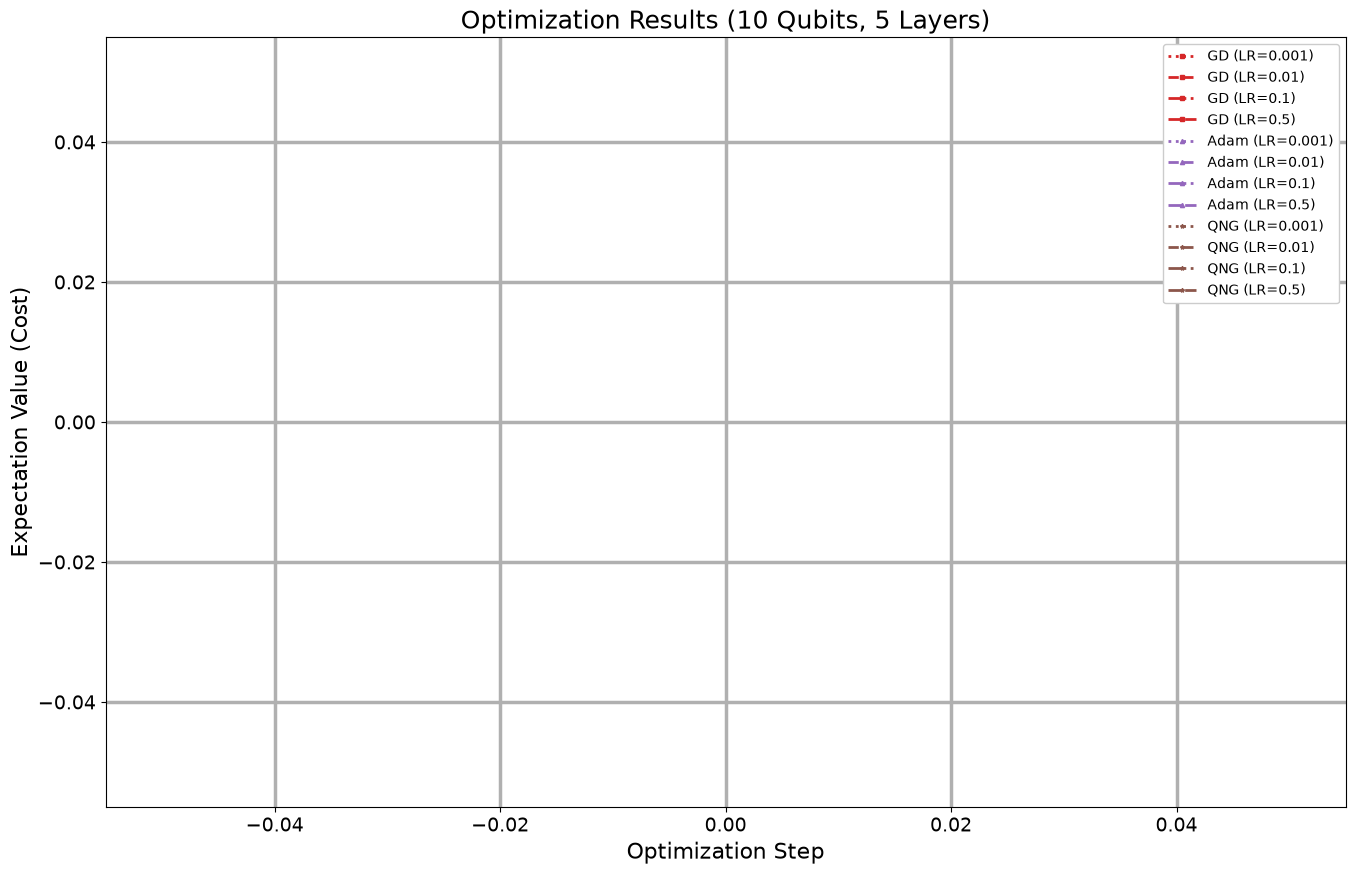

Saved plot: results/10q_5l.png


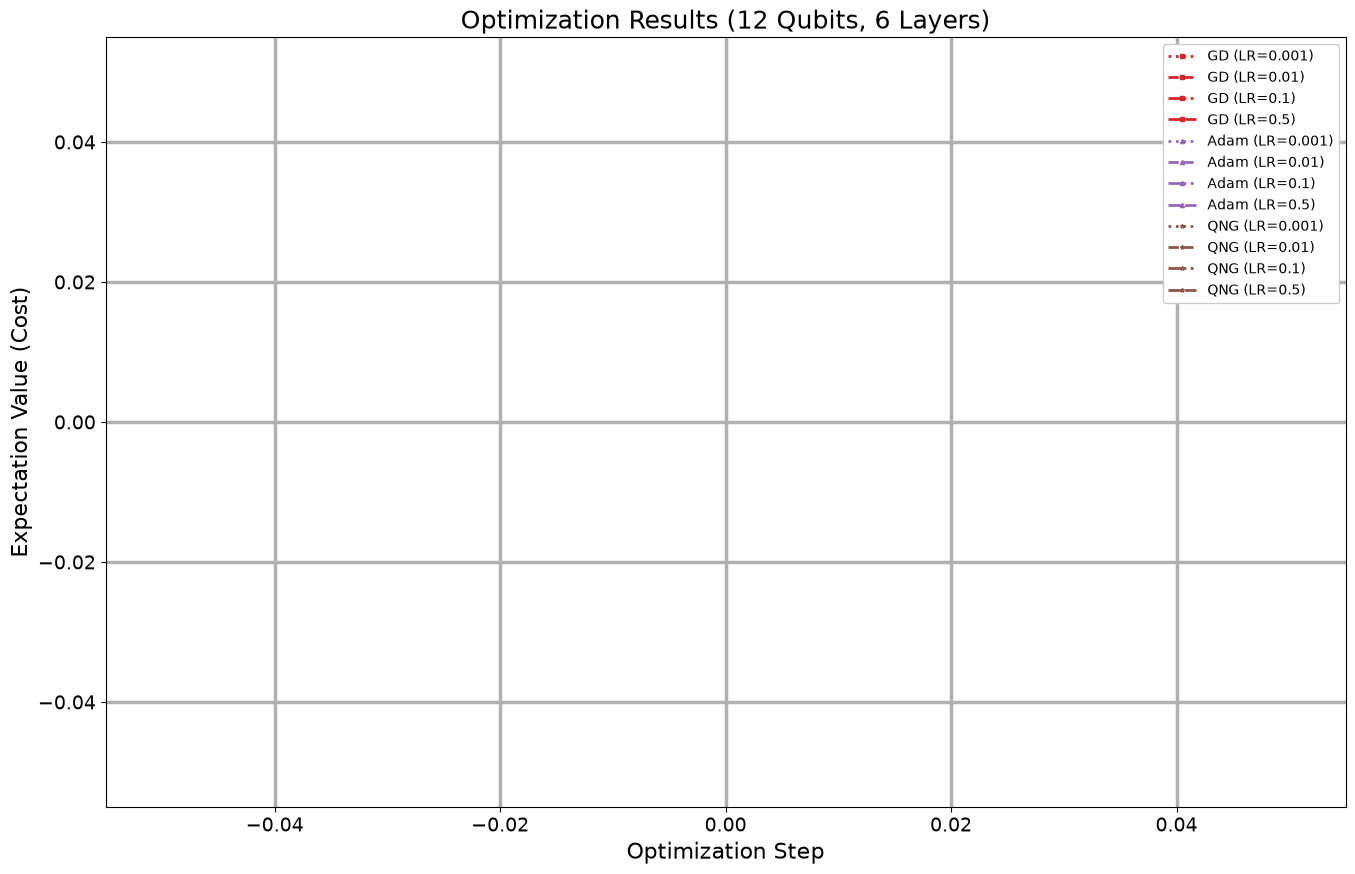

Saved plot: results/12q_6l.png


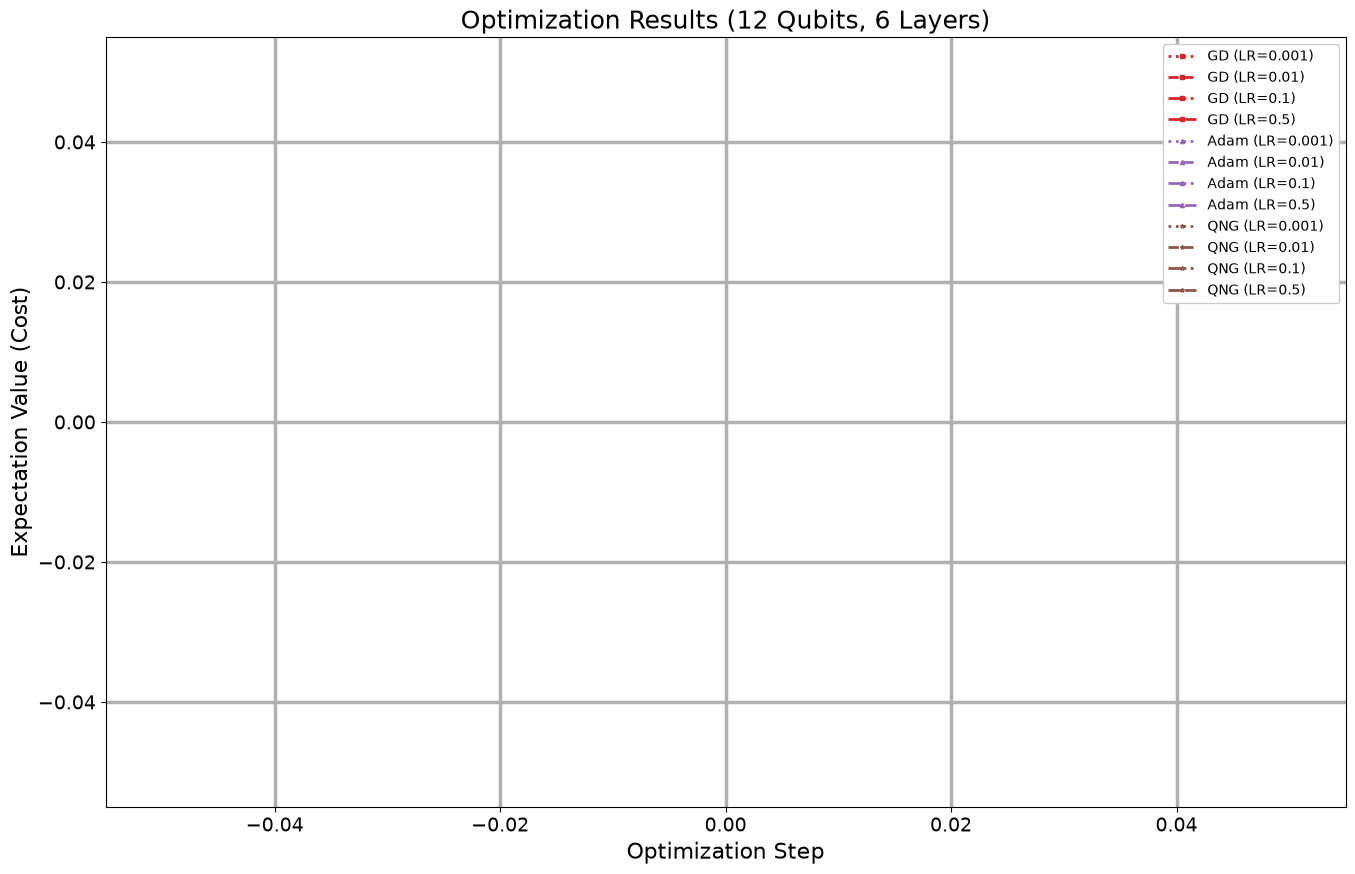

Saved plot: results/12q_6l_stopped.png


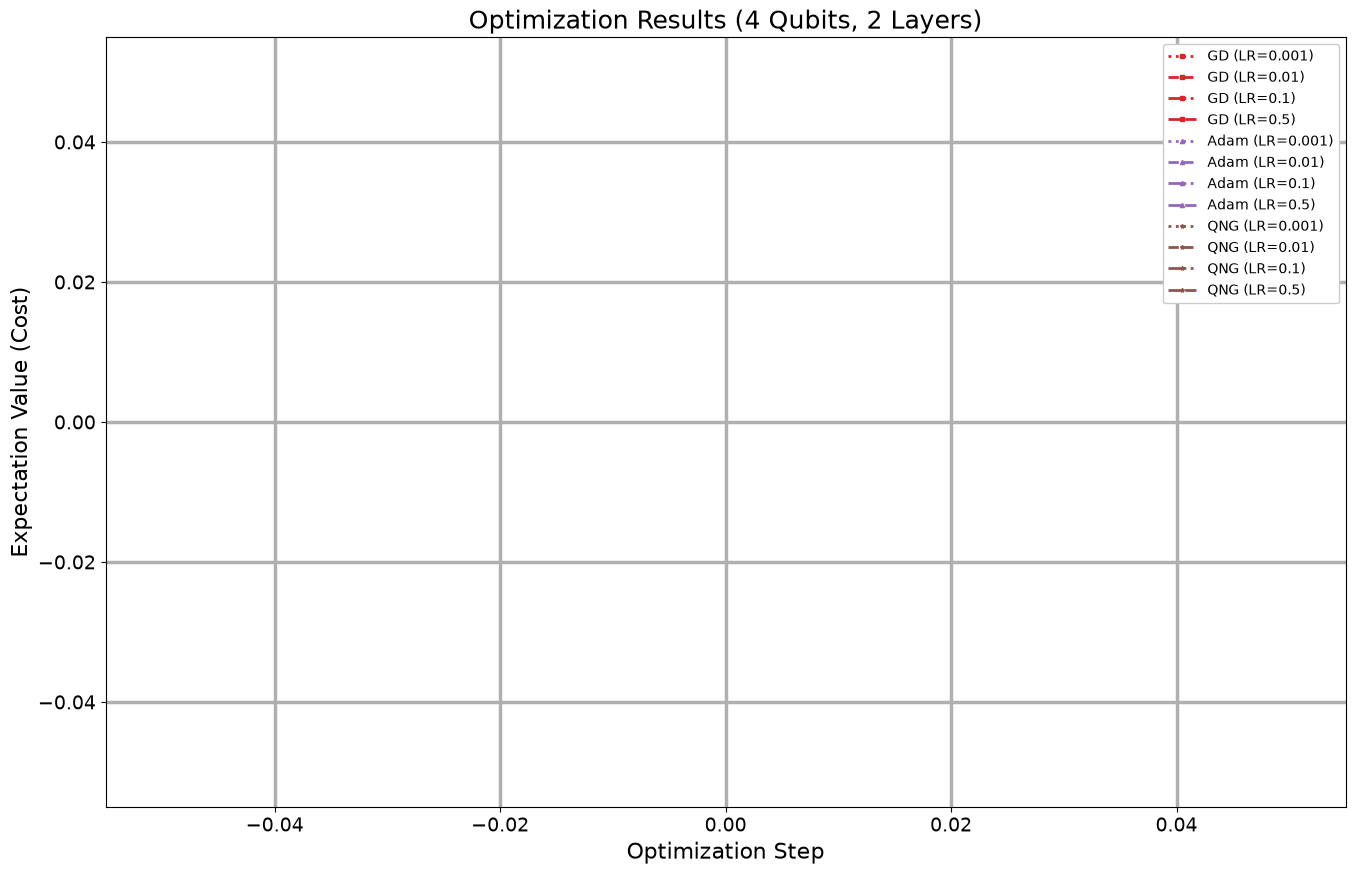

Saved plot: results/4q_2l.png


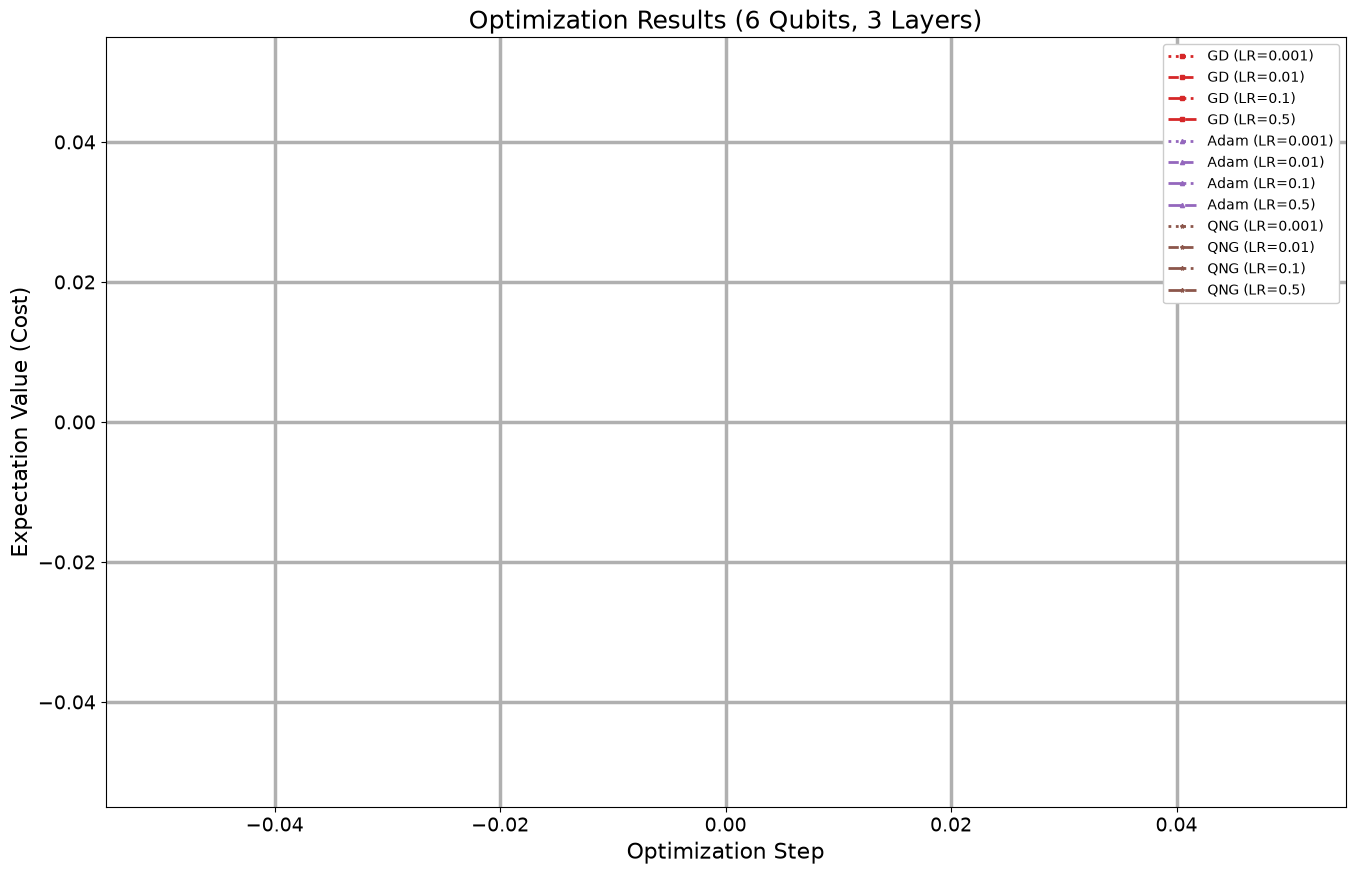

Saved plot: results/6q_3l.png


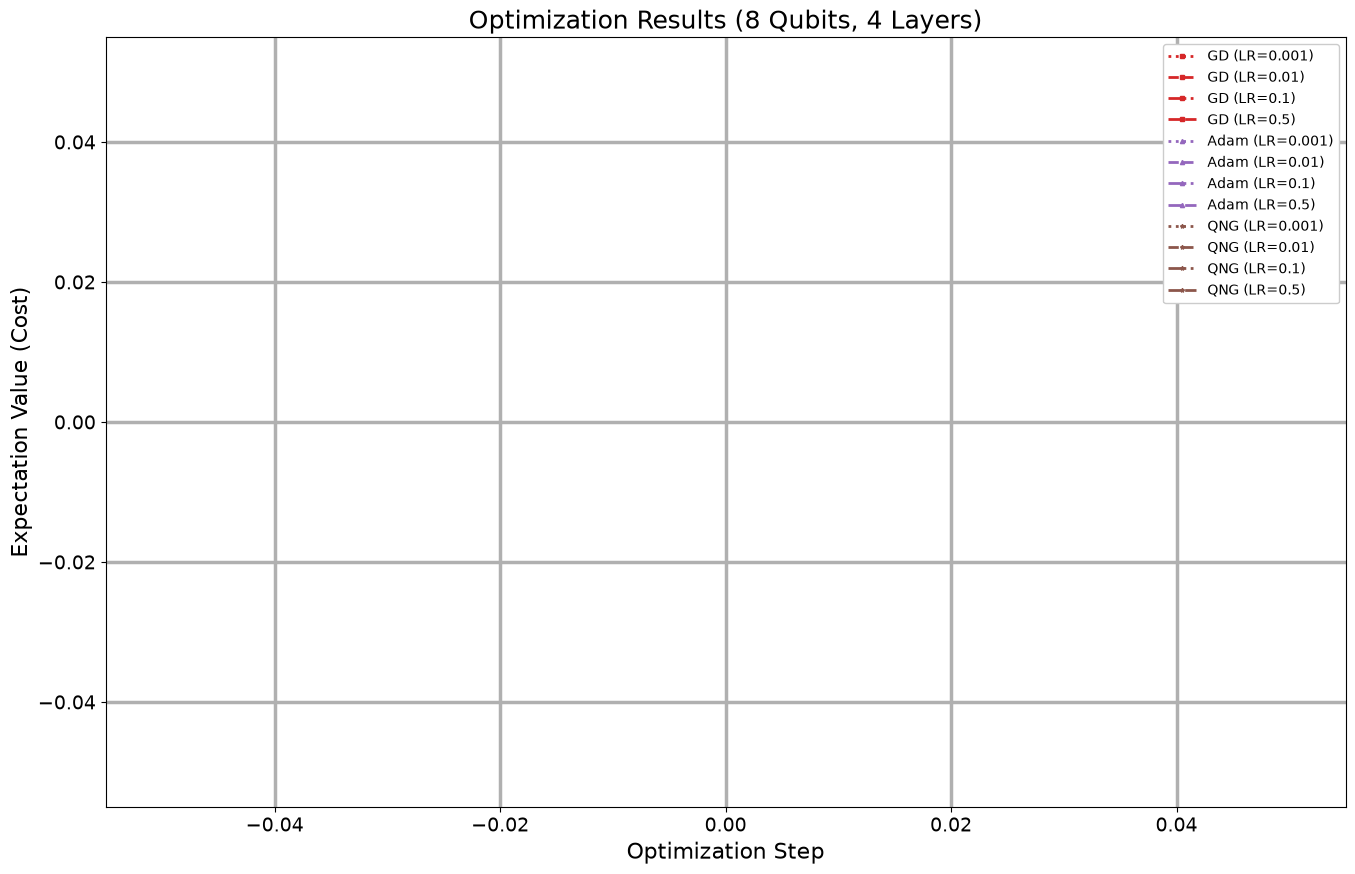

Saved plot: results/8q_4l.png


In [26]:
import os
import json
import matplotlib.pyplot as plt

# Directory containing the JSON result files
save_dir = "results"

# Look for all JSON files in the results directory
json_files = [f for f in os.listdir(save_dir) if f.endswith(".json")]

for json_file in json_files:
    json_path = os.path.join(save_dir, json_file)
    
    with open(json_path, "r") as f:
        data = json.load(f)
    
    num_qubits = data.get("num_qubits", "Unknown")
    num_layers = data.get("num_layers", "Unknown")
    
    # Setup plot with the exact figure size and style
    plt.figure(figsize=(16, 10))
    
    # 1. Plot Polyak -> GD and Polyak -> QNG (Best Curves)
    if "polyak_gd" in data and "best_loss 1" in data["polyak_gd"]:
        # Average across runs if multiple runs exist, or plot run 1
        best_gd = data["polyak_gd"]["best_loss 1"]
        plt.plot(best_gd, marker='o', markersize=3, linestyle='-', color='black', linewidth=4, label="Polyak -> GD (best so far)")
        
    if "polyak_qng" in data and "best_loss 1" in data["polyak_qng"]:
        best_qng = data["polyak_qng"]["best_loss 1"]
        plt.plot(best_qng, marker='d', markersize=3, linestyle='-', color='tab:cyan', linewidth=3, label="Polyak -> QNG (best so far)")
    
    # Line styles for learning rate variations
    styles = [':', '--', '-.', (0, (5, 1))]
    
    # 2. Plot SGD / GD curves
    if "sgd" in data:
        for j, (lr_key, lr_data) in enumerate(data["sgd"].items()):
            lr_val = lr_key.replace("lr_", "")
            curve = lr_data.get("loss 1", [])
            style = styles[j % len(styles)]
            plt.plot(curve, marker='s', markersize=3, linestyle=style, color='tab:red', linewidth=2, label=f"GD (LR={lr_val})")
            
    # 3. Plot Adam curves
    if "adam" in data:
        for j, (lr_key, lr_data) in enumerate(data["adam"].items()):
            lr_val = lr_key.replace("lr_", "")
            curve = lr_data.get("loss 1", [])
            style = styles[j % len(styles)]
            plt.plot(curve, marker='^', markersize=3, linestyle=style, color='tab:purple', linewidth=2, label=f"Adam (LR={lr_val})")
            
    # 4. Plot QNG curves
    if "qng" in data:
        for j, (lr_key, lr_data) in enumerate(data["qng"].items()):
            lr_val = lr_key.replace("lr_", "")
            curve = lr_data.get("loss 1", [])
            style = styles[j % len(styles)]
            plt.plot(curve, marker='*', markersize=3, linestyle=style, color='tab:brown', linewidth=2, label=f"QNG (LR={lr_val})")

    # Axis Labels, Formatting & Grid
    plt.title(f"Optimization Results ({num_qubits} Qubits, {num_layers} Layers)", fontsize=18)
    plt.xlabel("Optimization Step", fontsize=16)
    plt.ylabel("Expectation Value (Cost)", fontsize=16)
    plt.tick_params(labelsize=14)
    plt.legend(fontsize=10, framealpha=1, loc='upper right')
    plt.grid(True, linewidth=2.5)
    
    # Save image with matching filename (e.g., results/4q_2l.png)
    image_filename = os.path.splitext(json_file)[0] + ".png"
    save_img_path = os.path.join(save_dir, image_filename)
    
    plt.savefig(save_img_path, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    
    print(f"Saved plot: {save_img_path}")

In [ ]:
# import pennylane as qml
# import torch

# # Standard PennyLane device (works on Windows)
# dev = qml.device("default.qubit", wires=num_qubits)

# @qml.qnode(dev, interface="torch")
# def circuit(params):
#     qml.RX(params[0], wires=0)
#     qml.RY(params[1], wires=1)
#     return qml.expval(qml.PauliZ(0))

# # Move input parameters directly to GPU memory
# params = torch.tensor([0.5, 0.1], requires_grad=True, device="cuda")

# # Run on GPU via PyTorch interface
# result = circuit(params)
# print("Result on GPU:", result)